# Shear and Moment Calculator

In [1]:
# Import the required libraries
import math
import numpy as np
import plotly as py 

# import graph objects 
import plotly.graph_objs as go 

# ensure that graphs are plotted within the notebook - not in browser
py.offline.init_notebook_mode(connected = True)

In [2]:
# Initialise containers loads to prevent errors if no loads are input by the user
pointLoads = np.array([[]])
pointMoments = np.array([[]])
uniformlyDistributedLoads = np.array([[]])
linearlyVaryingDistributedLoads = np.array([[]])

## User inputs

In [3]:
# Input the span and force data
# Span length
span = 15

# Left support distance from left edge of beam
A = 0

# Right support distance from left edge of beam
B = 15

# Force data as an array where each row is a new force with the following arrangement
# [force distance from left edge of beam, horizontal force magnitude, vertical force magnitude]
pointLoads = np.array([[12, 0, -40]])

# [moment distance from left edge of beam, moment magnitude]
# pointMoments = np.array([[17, 50]])

# [position of start of UDL, position of end of UDL, magnitude of UDL
uniformlyDistributedLoads = np.array([[0, 5, -5], [5, 10, -20], [10, 15, -3]])

# [position of start of LVDL, position of end of LVDL, start magnitude of LVDL, end magnitude of LVDL
# linearlyVaryingDistributedLoads = np.array([[8, 17, -10, 0]])

## Defaults and initialisations

In [4]:
# Number of beam divisions
divs = 10000

# Distance between divisions
delta = span/divs

# Get the range of x coordinates
X = np.arange(0, span + delta, delta)

# Determine if there are any point load inputs - check if the pointLoads array is empty
nPL = len(pointLoads[0])

# Determine if there are any point moment inputs - check if the pointMoments array is empty
nPM = len(pointMoments[0])

# Determine if there are any uniformly distributed load inputs - check if the uniformlyDistributedLoads array is empty
nUDL = len(uniformlyDistributedLoads[0])

# Determine if there are any lienarly varying distributed load inputs - check if the linearlyVaryingDistributedLoads array is empty
nLVDL = len(linearlyVaryingDistributedLoads[0])

# initialise an array full of float numbers to hold the reactions [Vertical reaction at A, Horizontal reaction at A, Vertical reaction at B]
reactions = np.array([0.0, 0.0, 0.0])
    
# initialise an empty 2D array to hold the shear forces at each beam division location
shearForce = np.empty([0, len(X)])

# initialise an empty 2D array to hold the bending moments at each beam division location
bendingMoment = np.empty([0, len(X)])

## Reaction Calculations

**Define a function to calculate the reactions due to each defined point load**

In [5]:
# Define a function that takes n, the current point load within the point load array that we are calculating
def reactions_PL(n):

    # extract the location of the point load for the nth point load
    xp = pointLoads[n, 0]

    # extract the horizontal magnitude of the point load for the nth point load
    fx = pointLoads[n, 1]

    # extract the vertical magnitude of the point load for the nth point load
    fy = pointLoads[n, 2]

    # Get the lever arm of the moment generated by the point load about support A
    la_p = xp - A

    # Determine the moment generated by the point load about support A
    mp = fy*la_p

    # Get the lever arm of the moment generated by the reaction of support B about support A
    la_vb = B - A

    # Determine the vertical reaction at support B by taking the sum of moments about support A
    Vb = -mp/la_vb

    # Determine the vertical reaction at support A by taking the sum of the vertical forces
    Va = -fy - Vb
    
    # Determine the horizontal reaction at support A by taking the sum of the horizontal forces
    Ha = -fx

    # Return the reactions calculated for this point load
    return Va, Ha, Vb

**Define a function to calculate the reactions due to each defined point moment**

In [6]:
def reactions_PM(n):

    # extract the location of the point moment for the nth point moment
    xm = pointMoments[n, 0]

    # extract the magnitude of the nth point moment
    m = pointMoments[n, 1]
     
    # Get the lever arm of the moment generated by the reaction of support B about support A
    la_vb = B - A
    
    # Determine the vertical reaction at support B by taking the sum of moments about support A
    Vb = m/la_vb

    # Determine the vertical reaction at support A by taking the sum of the vertical forces
    Va = - Vb

    return Va, Vb

**Define a function to calculate the reactions due to each defined uniformly distributed load**

In [7]:
def reactions_UDL(n):

    # extract the start location of the UDL for the nth UDL
    xStart = uniformlyDistributedLoads[n, 0]

    # extract the end location of the UDL for the nth UDL
    xEnd = uniformlyDistributedLoads[n, 1]

    # extract the magnitude of the nth UDL
    fy = uniformlyDistributedLoads[n, 2]
     
    # Determine the resultant of the UDL 
    fy_res = fy * (xEnd - xStart)

    # Determine the position of the resultant of the UDL from the left end of the beam 
    x_res = xStart + 0.5 * (xEnd - xStart)
    
    # Get the lever arm of the moment generated by the UDL about support A
    la_UDL = x_res - A

    # Determine the moment generated by the point load about support A
    mUDL = fy_res*la_UDL

    # Get the lever arm of the moment generated by the reaction of support B about support A
    la_vb = B - A

    # Determine the vertical reaction at support B by taking the sum of moments about support A
    Vb = -mUDL/la_vb

    # Determine the vertical reaction at support A by taking the sum of the vertical forces
    Va = -fy_res - Vb

    # Return the reactions calculated for this point load
    return Va, Vb

**Define a function to calculate the reactions due to each defined linearly varying distributed load**

In [8]:
def reactions_LVDL(n):

    # extract the start location of the LVDL for the nth LVDL
    xStart = linearlyVaryingDistributedLoads[n, 0]

    # extract the end location of the LVDL for the nth LVDL
    xEnd = linearlyVaryingDistributedLoads[n, 1]

    # extract the starting magnitude of the nth LVDL
    fy_Start = linearlyVaryingDistributedLoads[n, 2]
    
    # extract the end magnitude of the nth LVDL
    fy_End = linearlyVaryingDistributedLoads[n, 3]

    # Determine whether the start or the end of the distributed load is the non zero end
    if abs(fy_Start) > 0:
        
        # Determine the resultant of the LVDL 
        fy_res = 0.5 * fy_Start * (xEnd - xStart)

        # Determine the position of the resultant of the LVDL from the left end of the beam 
        x_res = xStart + (1/3) * (xEnd - xStart)

    else:
        # Determine the resultant of the LVDL 
        fy_res = 0.5 * fy_End * (xEnd - xStart)

        # Determine the position of the resultant of the LVDL from the left end of the beam 
        x_res = xStart + (2/3) * (xEnd - xStart)
    
    # Get the lever arm of the moment generated by the UDL about support A
    la_LVDL = x_res - A

    # Determine the moment generated by the point load about support A
    mLVDL = fy_res*la_LVDL

    # Get the lever arm of the moment generated by the reaction of support B about support A
    la_vb = B - A

    # Determine the vertical reaction at support B by taking the sum of moments about support A
    Vb = -mLVDL/la_vb

    # Determine the vertical reaction at support A by taking the sum of the vertical forces
    Va = -fy_res - Vb

    # Return the reactions calculated for this point load
    return Va, Vb

**Cycle through all point loads and determine reactions**

In [9]:
# Initialise an empty array to store the reactions - the array has 0 rows and 3 columns
PL_record = np.empty([0, 3])

# Check if there are point loads to account for
if(nPL > 0):

    # Loop through the point loads 
    for n, p in enumerate(pointLoads):

        # Use the point load reactions function to determine the reactions due to each point load
        va, ha, vb = reactions_PL(n)
        
        # Store the set of reactions for each point load
        PL_record = np.append(PL_record, [np.array([va, ha, vb])], axis = 0)

        # Add reactions to the record
        reactions[0] = reactions[0] + va
        reactions[1] = reactions[1] + ha
        reactions[2] = reactions[2] + vb
        

**Cycle through all point moments and determine reactions**

In [10]:
# Initialise an empty array to store the reactions - the array has 0 rows and 2 columns
PM_record = np.empty([0, 2])

# Check if there are point moments to account for
if(nPM > 0):

    # Loop through the point moments
    for n, m in enumerate(pointMoments):

        # Use the point load reactions function to determine the reactions due to each point moment
        va, vb = reactions_PM(n)
        
        # Store the set of reactions for each point moment
        PM_record = np.append(PM_record, [np.array([va, vb])], axis = 0)

        # Add reactions to the record
        reactions[0] = reactions[0] + va
        reactions[2] = reactions[2] + vb
        

**Cycle through all UDLs and determine reactions**

In [11]:
# Initialise an empty array to store the reactions - the array has 0 rows and 2 columns
UDL_record = np.empty([0, 2])

# Check if there are UDLs to account for
if(nUDL > 0):

    # Loop through the UDLs
    for n, u in enumerate(uniformlyDistributedLoads):

        # Use the UDL reactions function to determine the reactions due to each UDL
        va, vb = reactions_UDL(n)
        
        # Store the set of reactions for each UDL
        UDL_record = np.append(UDL_record, [np.array([va, vb])], axis = 0)

        # Add reactions to the record
        reactions[0] = reactions[0] + va
        reactions[2] = reactions[2] + vb
        

**Cycle through all LVDLs and determine reactions**

In [12]:
# Initialise an empty array to store the reactions - the array has 0 rows and 2 columns
LVDL_record = np.empty([0, 2])

# Check if there are LVDLs to account for
if(nLVDL > 0):

    # Loop through the LVDLs
    for n, l in enumerate(linearlyVaryingDistributedLoads):

        # Use the LVDL reactions function to determine the reactions due to each linearly varying distributed load
        va, vb = reactions_LVDL(n)
        
        # Store the set of reactions for each linearly varying distributed load
        LVDL_record = np.append(LVDL_record, [np.array([va, vb])], axis = 0)

        # Add reactions to the record
        reactions[0] = reactions[0] + va
        reactions[2] = reactions[2] + vb

<hr>

## Shear and Moment Calculation

**Define function to calculate the shear forces and bending moments due to the applied point loads**

In [13]:
def shear_moment_PL(n):
    
    # extract the location of the point load for the nth point load
    xp = pointLoads[n, 0]

    # extract the vertical magnitude of the point load for the nth point load
    fy = pointLoads[n, 2]

    # extract the vertical reaction at support A for the nth point load
    Va = PL_record[n, 0]

    # extract the vertical reaction at support B for the nth point load
    Vb = PL_record[n, 2]

    # Initialise an array that will store the shear force at each point along the beam
    Shear = np.zeros(len(X))

     # Initialise an array that will store the bending moment at each point along the beam
    Moment = np.zeros(len(X))
    
    # Cycle through each division point along the beam to determine the internal shear and bending moments
    for i, x in enumerate(X):

        # Initialise the shear force and bending moment as zero at this location along the beam
        shear = 0
        moment = 0

        # Calculate the shear force and bending moment due to the reaction at support A if applicable
        if x > A:

            # Add the contribution of the reaction at support A to the total internal shear force at point x
            shear = shear + Va

            # Add the contribution of the reaction at support A to the total internal bending moment at point x
            moment = moment + Va*(x-A)
            
        # Calculate the shear force and bending moment due to the reaction at support B if applicable
        if x > B:
            
            # Add the contribution of the reaction at support B to the total internal shear force at point x
            shear = shear + Vb

            # Add the contribution of the reaction at support B to the total internal bending moment at point x
            moment = moment + Vb*(x-B)
            
        # Calculate the shear force and bending moment due to the applied point load if applicable
        if x > xp:

            # Add the contribution of the point load to the total internal shear force at point x
            shear = shear + fy

            # Add the contribution of the point load to the total internal bending moment at point x
            moment = moment + fy*(x-xp)
            
        # Store the shear and moment for this location
        Shear[i] = shear
        Moment[i] = moment

    return Shear, Moment

**Define function to calculate the shear forces and bending moments due to the applied point moments**

In [14]:
def shear_moment_PM(n):
    
    # extract the location of the point moment for the nth point load
    xm = pointMoments[n, 0]

    # extract the magnitude of the nth point moment
    m = pointMoments[n, 1]

    # extract the vertical reaction at support A for the nth point moment
    Va = PM_record[n, 0]

    # extract the vertical reaction at support B for the nth point moment
    Vb = PM_record[n, 1]

    # Initialise an array that will store the shear force at each point along the beam
    Shear = np.zeros(len(X))

     # Initialise an array that will store the bending moment at each point along the beam
    Moment = np.zeros(len(X))
    
    # Cycle through each division point along the beam to determine the internal shear and bending moments
    for i, x in enumerate(X):

        # Initialise the shear force and bending moment as zero at this location along the beam
        shear = 0
        moment = 0

        # Calculate the shear force and bending moment due to the reaction at support A if applicable
        if x > A:

            # Add the contribution of the reaction at support A to the total internal shear force at point x
            shear = shear + Va

            # Add the contribution of the reaction at support A to the total internal bending moment at point x
            moment = moment + Va*(x-A)
            
        # Calculate the shear force and bending moment due to the reaction at support B if applicable
        if x > B:
            
            # Add the contribution of the reaction at support B to the total internal shear force at point x
            shear = shear + Vb

            # Add the contribution of the reaction at support B to the total internal bending moment at point x
            moment = moment + Vb*(x-B)
            
        # Calculate the shear force and bending moment due to the applied point moment if applicable
        if x > xm:

            # Add the contribution of the point moment to the total internal bending moment at point x
            moment = moment + m
            
        # Store the shear and moment for this location
        Shear[i] = shear
        Moment[i] = moment

    return Shear, Moment

**Define function to calculate the shear forces and bending moments due to the applied UDLs**

In [15]:
def shear_moment_UDL(n):
    
    # extract the start location of the UDL for the nth UDL
    xStart = uniformlyDistributedLoads[n, 0]

    # extract the end location of the UDL for the nth UDL
    xEnd = uniformlyDistributedLoads[n, 1]

    # extract the magnitude of the nth UDL
    fy = uniformlyDistributedLoads[n, 2]

    # extract the vertical reaction at support A for the nth UDL
    Va = UDL_record[n, 0]

    # extract the vertical reaction at support B for the nth UDL
    Vb = UDL_record[n, 1]

    # Initialise an array that will store the shear force at each point along the beam
    Shear = np.zeros(len(X))

    # Initialise an array that will store the bending moment at each point along the beam
    Moment = np.zeros(len(X))
    
    # Cycle through each division point along the beam to determine the internal shear and bending moments
    for i, x in enumerate(X):

        # Initialise the shear force and bending moment as zero at this location along the beam
        shear = 0
        moment = 0

        # Calculate the shear force and bending moment due to the reaction at support A if applicable
        if x > A:

            # Add the contribution of the reaction at support A to the total internal shear force at point x
            shear = shear + Va

            # Add the contribution of the reaction at support A to the total internal bending moment at point x
            moment = moment + Va*(x-A)
            
        # Calculate the shear force and bending moment due to the reaction at support B if applicable
        if x > B:
            
            # Add the contribution of the reaction at support B to the total internal shear force at point x
            shear = shear + Vb

            # Add the contribution of the reaction at support B to the total internal bending moment at point x
            moment = moment + Vb*(x-B)
            
        # Calculate the shear force and bending moment due to the applied UDL if applicable
        # Check if we are part way through the UDL
        if x > xStart and x <= xEnd:

            # Add the contribution of the partial UDL to the total internal shear force at point x
            shear = shear + fy * (x - xStart)

            # Add the contribution of the partial UDL to the total internal bending moment at point x
            moment = moment + fy * (x - xStart) * 0.5 * (x - xStart)

        # Check if we are beyond the UDL 
        elif x > xEnd:

            # Add the contribution of the full UDL to the total internal shear force at point x
            shear = shear + fy * (xEnd - xStart)

            # Add the contribution of the full UDL to the total internal bending moment at point x
            moment = moment + fy * (xEnd - xStart) *((x - xEnd) + 0.5 * (xEnd - xStart))
            
        # Store the shear and moment for this location
        Shear[i] = shear
        Moment[i] = moment

    return Shear, Moment

**Define function to calculate the shear forces and bending moments due to the applied LVDLs**

In [16]:
def shear_moment_LVDL(n):
    
    # extract the start location of the LVDL for the nth LVDL
    xStart = linearlyVaryingDistributedLoads[n, 0]

    # extract the end location of the LVDL for the nth LVDL
    xEnd = linearlyVaryingDistributedLoads[n, 1]

    # extract the left end magnitude of the nth LVDL
    fy_Start = linearlyVaryingDistributedLoads[n, 2]

    # extract the right end magnitude of the nth LVDL
    fy_End = linearlyVaryingDistributedLoads[n, 3]

    # extract the vertical reaction at support A for the nth LVDL
    Va = LVDL_record[n, 0]

    # extract the vertical reaction at support B for the nth LVDL
    Vb = LVDL_record[n, 1]

    # Initialise an array that will store the shear force at each point along the beam
    Shear = np.zeros(len(X))

    # Initialise an array that will store the bending moment at each point along the beam
    Moment = np.zeros(len(X))
    
    # Cycle through each division point along the beam to determine the internal shear and bending moments
    for i, x in enumerate(X):

        # Initialise the shear force and bending moment as zero at this location along the beam
        shear = 0
        moment = 0

        # Calculate the shear force and bending moment due to the reaction at support A if applicable
        if x > A:

            # Add the contribution of the reaction at support A to the total internal shear force at point x
            shear = shear + Va

            # Add the contribution of the reaction at support A to the total internal bending moment at point x
            moment = moment + Va*(x-A)
            
        # Calculate the shear force and bending moment due to the reaction at support B if applicable
        if x > B:
            
            # Add the contribution of the reaction at support B to the total internal shear force at point x
            shear = shear + Vb

            # Add the contribution of the reaction at support B to the total internal bending moment at point x
            moment = moment + Vb*(x-B)
            
        # Calculate the shear force and bending moment due to the applied LVDL if applicable
        # Check if we are part way through the LVDL
        if x > xStart and x <= xEnd:

            if abs(fy_Start) > 0:

                # determine the width of the distributed load at the left of the cut
                x_base = x - xStart
                
                # determine the magnitude of the distributed load at the cut location
                fy_cut = fy_Start - ((x_base * fy_Start)/(xEnd - xStart))

                # calculate the resultant of the traingular portion of the load
                R1 = 0.5 * x_base * (fy_Start - fy_cut)
                
                # calculate the lever arm of the traingular portion of the load 
                la_R1 = (2/3) * x_base
                
                # calculate the resultant for the rectangular portion of the load 
                R2 = x_base * fy_cut
                
                # calculate the lever arm of the rectangular portion of the load 
                la_R2 = 0.5 * x_base
                
                # Add the contribution of the partial LVDL to the total internal shear force at point x
                shear = shear + R1 + R2

                # Add the contribution of the partial LVDL to the total internal bending moment at point x
                moment = moment + R1 * la_R1 + R2 * la_R2

            else:

                # determine the width of the distributed load at the left of the cut
                x_base = x - xStart
                
                # determine the magnitude of the distributed load at the cut location
                fy_cut = (fy_End * x_base)/(xEnd - xStart)

                # calculate the resultant of the applied load
                R = 0.5 * x_base * fy_cut
                
                # calculate the lever arm of the applied load 
                la_R = (1/3) * x_base
                
                # Add the contribution of the partial LVDL to the total internal shear force at point x
                shear = shear + R

                # Add the contribution of the partial LVDL to the total internal bending moment at point x
                moment = moment + R * la_R

        # Check if we are beyond the UDL 
        elif x > xEnd:
            
            if abs(fy_Start) > 0:

                # calculate the resultant of the LVDL
                R = 0.5 * fy_Start * (xEnd - xStart)
                
                # calculate the lever arm of the LVDL 
                la_R = x - xStart - (1/3) * (xEnd - xStart)
                
                # Add the contribution of the LVDL to the total internal shear force at point x
                shear = shear + R

                # Add the contribution of the LVDL to the total internal bending moment at point x
                moment = moment + R * la_R

            else:

               # calculate the resultant of the LVDL
                R = 0.5 * fy_End * (xEnd - xStart)
                
                # calculate the lever arm of the LVDL 
                la_R = x - xStart - (2/3) * (xEnd - xStart)
                
                # Add the contribution of the LVDL to the total internal shear force at point x
                shear = shear + R

                # Add the contribution of the LVDL to the total internal bending moment at point x
                moment = moment + R * la_R
            
        # Store the shear and moment for this location
        Shear[i] = shear
        Moment[i] = moment

    return Shear, Moment

**Cycle through all point loads and determine shear force and bending moments**

In [17]:
# Check if there are point loads to account for
if(nPL > 0):

    # Loop through the point loads 
    for n, p in enumerate(pointLoads):

        # Use the shear force and bending moments calculation function to determine the internal forces generated due to each point moment
        Shear, Moment = shear_moment_PL(n)
        
        # Store the internal shear force due to the point moment at each location
        shearForce = np.append(shearForce, [Shear], axis = 0)

        # Store the internal bending moment due to the point moment at each location
        bendingMoment = np.append(bendingMoment, [Moment], axis = 0)

**Cycle through all point moments and determine the shear force and bending moments**

In [18]:
# Check if there are point moments to account for
if(nPM > 0):

    # Loop through the point moments 
    for n, m in enumerate(pointMoments):

        # Use the shear force and bending moments calculation function to determine the internal forces generated due to each point moment
        Shear, Moment = shear_moment_PM(n)
        
        # Store the internal shear force due to the point moments at each location
        shearForce = np.append(shearForce, [Shear], axis = 0)

        # Store the internal bending moment due to the point moments at each location
        bendingMoment = np.append(bendingMoment, [Moment], axis = 0)

**Cycle through all UDLs and determine the shear force and bending moments**

In [19]:
# Check if there are UDLs to account for
if(nUDL > 0):

    # Loop through the UDLs 
    for n, u in enumerate(uniformlyDistributedLoads):

        # Use the shear force and bending moments calculation function to determine the internal forces generated due to each UDL
        Shear, Moment = shear_moment_UDL(n)
        
        # Store the internal shear force due to the UDLs at each location
        shearForce = np.append(shearForce, [Shear], axis = 0)

        # Store the internal bending moment due to the UDLs at each location
        bendingMoment = np.append(bendingMoment, [Moment], axis = 0)

**Cycle through all LVDLs and determine the shear force and bending moments**

In [20]:
# Check if there are LVDLs to account for
if(nLVDL > 0):

    # Loop through the LVDLs 
    for n, l in enumerate(linearlyVaryingDistributedLoads):

        # Use the shear force and bending moments calculation function to determine the internal forces generated due to each LVDL
        Shear, Moment = shear_moment_LVDL(n)
        
        # Store the internal shear force due to the LVDLs at each location
        shearForce = np.append(shearForce, [Shear], axis = 0)

        # Store the internal bending moment due to the LVDLs at each location
        bendingMoment = np.append(bendingMoment, [Moment], axis = 0)

<hr>

## Plotting and Printing

In [21]:
print('The vertical reaction at A is {one} kN'.format(one = round(reactions[0],2)))
print('The horizontal reaction at A is {one} kN'.format(one = round(reactions[1],2)))
print('The vertical reaction at B is {one} kN'.format(one = round(reactions[2],2)))

The vertical reaction at A is 81.33 kN
The horizontal reaction at A is 0.0 kN
The vertical reaction at B is 98.67 kN


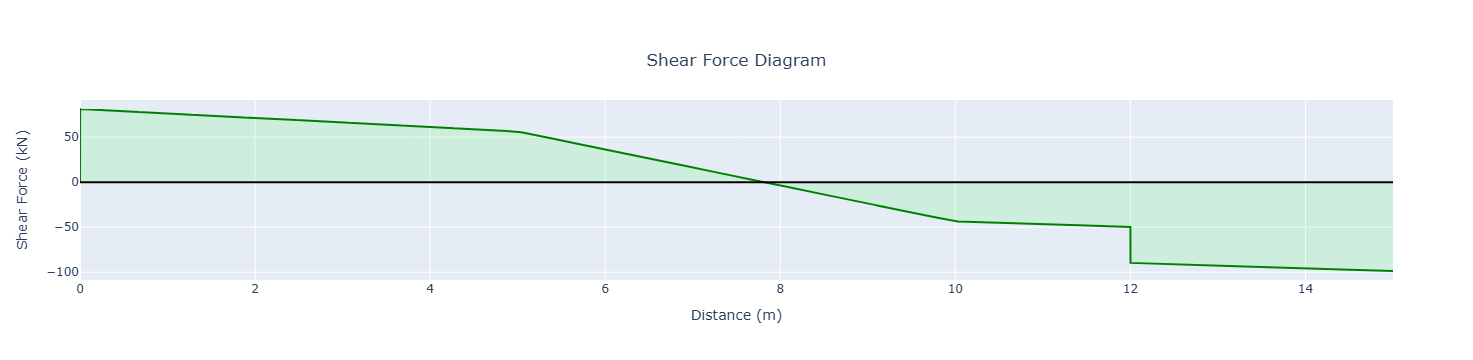

In [22]:
# Define the layout object
layout = go.Layout(
        title = {

            # Set the title
            'text': 'Shear Force Diagram', 
            
            # locate the title 85% of the way vertically from the bottom
            'y': 0.85,

            # Locate the title 50% of the way horizontally
            'x': 0.5,

            'xanchor': 'center',
            'yanchor': 'top'
        
        },
    
        yaxis = dict(

            # Set the y axis heading
            title = 'Shear Force (kN)'
        ),
    
        xaxis = dict(

            # Set the x axis heading
            title = 'Distance (m)', 

            # Optionally extend the plot to the left and right
            # range = [1, span+1]
        ),

        # Turn off the legend
        showlegend = False,
)

# Define the line that will be show the shear force values
line = go.Scatter(
    x = X,
    y = sum(shearForce),
    mode = 'lines',
    name = 'Shear Force',
    fill = 'tonexty',
    fillcolor = 'rgba(0,255,0,0.1)',
    line_color = 'green'
)

# Define a line to show the x axis 
axis = go.Scatter(
    x = [0, span],
    y = [0, 0],
    mode = 'lines',
    line_color = 'black'
)

# Generate the figure 
fig = go.Figure(data = [line, axis], layout = layout)
py.offline.iplot(fig)            

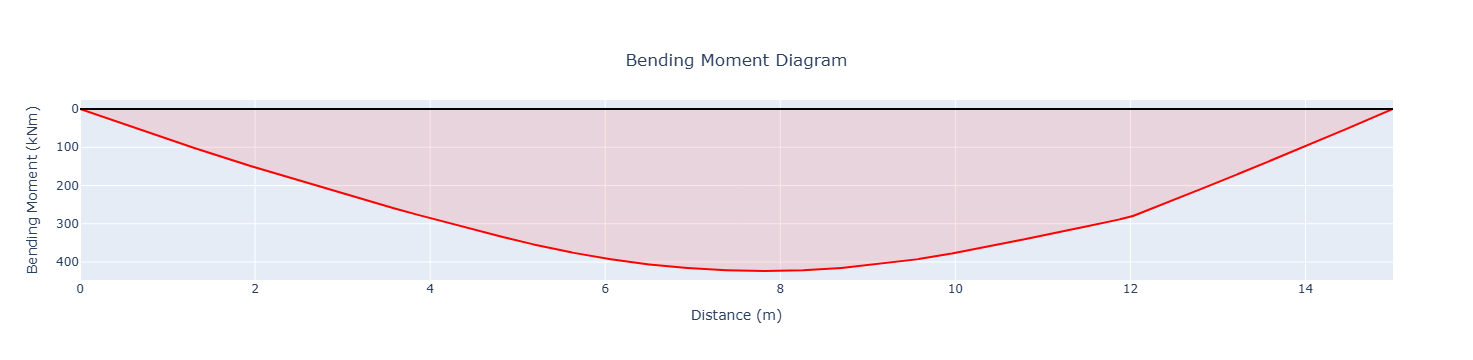

In [23]:
# Define the layout object
layout = go.Layout(
        title = {

            # Set the title
            'text': 'Bending Moment Diagram', 

            # locate the title 85% of the way vertically from the bottom
            'y': 0.85,

            # Locate the title 50% of the way horizontally
            'x': 0.5,

            'xanchor': 'center',

            'yanchor': 'top'
        
        },
    
        yaxis = dict(

            # Set the y axis heading
            title = 'Bending Moment (kNm)',

            # Optionally flip the vertical axis
            autorange = 'reversed'
        ),
    
        xaxis = dict(

            # Set the x axis heading
            title = 'Distance (m)', 

            # Optionally extend the plot to the left and right
            # range = [1, span+1]
        ),

        # Turn off the legend
        showlegend = False,
)

# Define the line that will be show the shear force values
line = go.Scatter(
    x = X,
    y = sum(bendingMoment),
    mode = 'lines',
    name = 'Bending Moment',
    fill = 'tonexty',
    fillcolor = 'rgba(255,0,0,0.1)',
    line_color = 'red'
)

# Define a line to show the x axis 
axis = go.Scatter(
    x = [0, span],
    y = [0, 0],
    mode = 'lines',
    line_color = 'black'
)

# Generate the figure 
fig = go.Figure(data = [line, axis], layout = layout)
py.offline.iplot(fig)          